### Airbnb Price Prediction and Feature-Based Market Analysis using Machine Learning

#### IMPORTING LIBRARIES

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

#### LOAD DATASET USING SMALLER SAMPLE

In [7]:
df = pd.read_csv("train.csv")
df = df.sample(n=10000, random_state=42)
print("Sample Shape:", df.shape)
print("Data Types:\n", df.dtypes.tolist())
print("Columns:", df.columns.tolist())
print("Missing Values:\n", df.isnull().sum())


Sample Shape: (10000, 29)
Data Types:
 [dtype('int64'), dtype('float64'), <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, dtype('int64'), dtype('float64'), <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, dtype('bool'), <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, dtype('float64'), dtype('float64'), <StringDtype(storage='python', na_value=nan)>, <StringDtype(storage='python', na_value=nan)>, dtype('int64'), dtype('float64'), <StringDtype(storage='python', na_value=nan)>, <StringD

#### DATA CLEANING

In [8]:
df = df.drop([
    'id', 'name', 'description', 'thumbnail_url',
    'first_review', 'last_review', 'host_since', 'amenities'
], axis=1, errors='ignore')

# Convert % to numeric
if 'host_response_rate' in df.columns:
    df['host_response_rate'] = df['host_response_rate'].str.replace('%', '')
    df['host_response_rate'] = pd.to_numeric(df['host_response_rate'], errors='coerce')

# Fill missing values
df = df.fillna(df.median(numeric_only=True))


#### OUTLIER REMOVAL

In [9]:
df = df[df['log_price'] < df['log_price'].quantile(0.99)]

#### FEATURE ENGINEERING

In [10]:
df['beds_per_room'] = df['beds'] / (df['bedrooms'] + 1)
df['reviews_per_listing'] = df['number_of_reviews'] / (df['accommodates'] + 1)

#### ENCODING

In [11]:
df = pd.get_dummies(df, drop_first=True)

df = df.fillna(df.median(numeric_only=True))
df = df.dropna()

print("After Cleaning Shape:", df.shape)


After Cleaning Shape: (9898, 1128)


#### FEATURES & TARGET

In [12]:
X = df.drop('log_price', axis=1)
y = df['log_price']

#### TRAIN TEST SPLIT

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### SCALING ~ FOR SVR

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### EVALUATION FUNCTION

In [15]:
def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("------------------------")
    
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} - Actual vs Predicted")
    plt.show()
    
    return rmse, r2


#### TRAIN MODELS
- Linear Regression
- Decision Tree
- Random Forest
- SVR 

Linear Regression
RMSE: 0.4000679718487258
R2 Score: 0.6501372400641607
------------------------


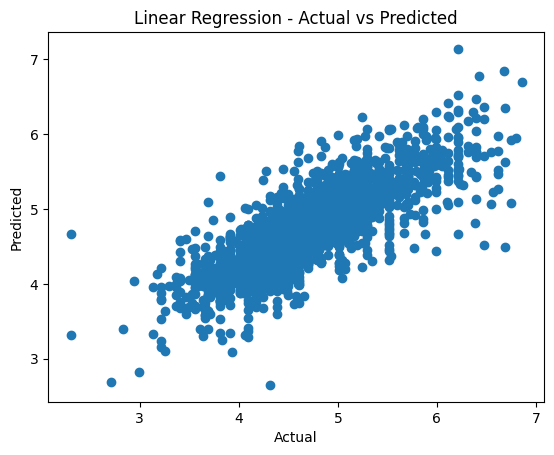

Decision Tree
RMSE: 0.50312346865005
R2 Score: 0.4466762642437577
------------------------


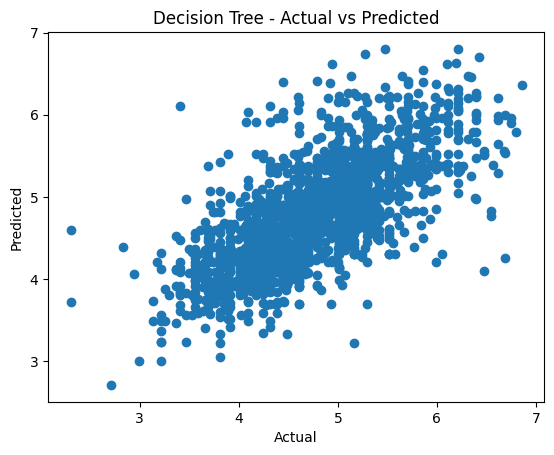

Random Forest
RMSE: 0.38615750666306986
R2 Score: 0.6740439006585002
------------------------


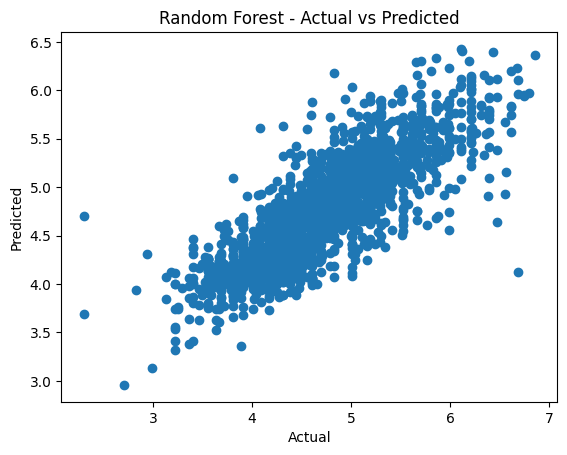

In [ ]:
results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results['Linear Regression'] = evaluate_model("Linear Regression", y_test, lr_pred)

# Decision Tree (tuned)
dt = DecisionTreeRegressor(max_depth=20, min_samples_split=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
results['Decision Tree'] = evaluate_model("Decision Tree", y_test, dt_pred)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = evaluate_model("Random Forest", y_test, rf_pred)

# SVR
svr = SVR(kernel='rbf', C=10, gamma='scale') 
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)
results['SVR'] = evaluate_model("SVR", y_test, svr_pred)


#### MODEL COMPARISON 


Model Comparison:

                       RMSE        R2
Linear Regression  0.400068  0.650137
Decision Tree      0.501536  0.450163
Random Forest      0.386199  0.673974
SVR                0.444205  0.568683


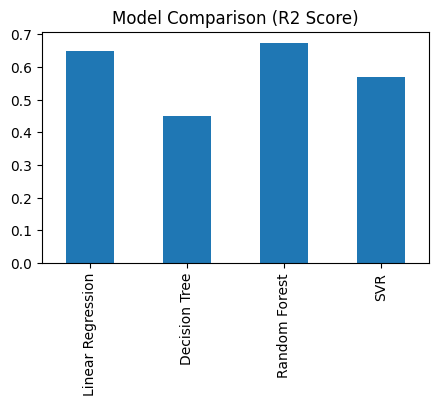

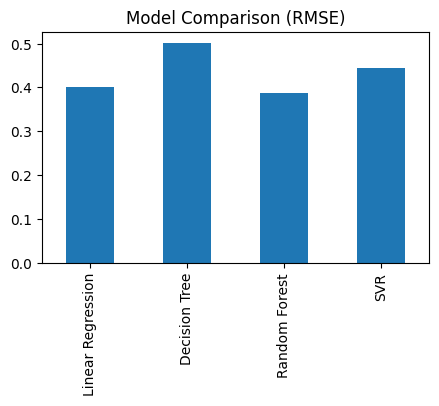

In [ ]:
comparison = pd.DataFrame(results, index=['RMSE', 'R2']).T

print("\nModel Comparison:\n")
print(comparison)

plt.figure(figsize=(5,3))
comparison['R2'].plot(kind='bar')
plt.title("Model Comparison (R2 Score)")
plt.show()

plt.figure(figsize=(5,3))
comparison['RMSE'].plot(kind='bar')
plt.title("Model Comparison (RMSE)")
plt.show()

#### FEATURE IMPORTANCE


Top Features:

                   Feature  Importance
33  room_type_Private room    0.316877
5                longitude    0.110592
8                 bedrooms    0.083848
34   room_type_Shared room    0.082747
4                 latitude    0.080813
1                bathrooms    0.065435
0             accommodates    0.028778
11     reviews_per_listing    0.026148
7     review_scores_rating    0.019263
6        number_of_reviews    0.013968


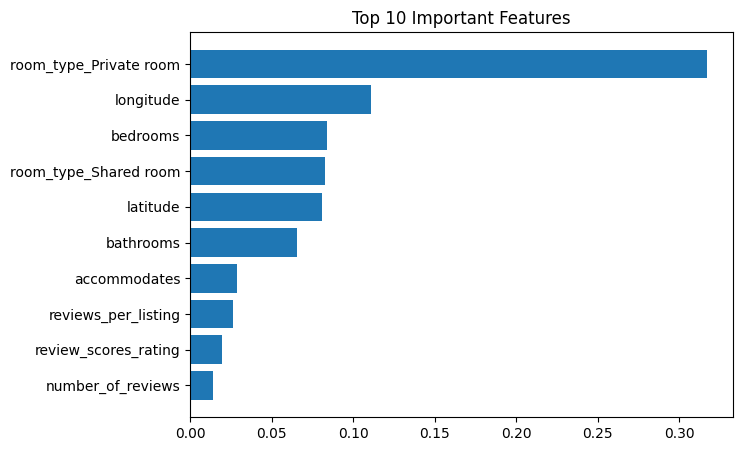

In [ ]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop Features:\n")
print(feat_df.head(10))

plt.figure(figsize=(7,5))
plt.barh(feat_df['Feature'][:10], feat_df['Importance'][:10])
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

#### SAMPLE PREDICTIONS


Sample Predictions:

   Actual Price  Predicted Price
0          60.0        79.244920
1          75.0        97.178795
2          52.0        60.203000
3          34.0        71.863372
4         139.0       158.197004
5         105.0       123.142477
6          65.0        59.096862
7         190.0       157.124568
8          39.0        62.013387
9         135.0       177.669081


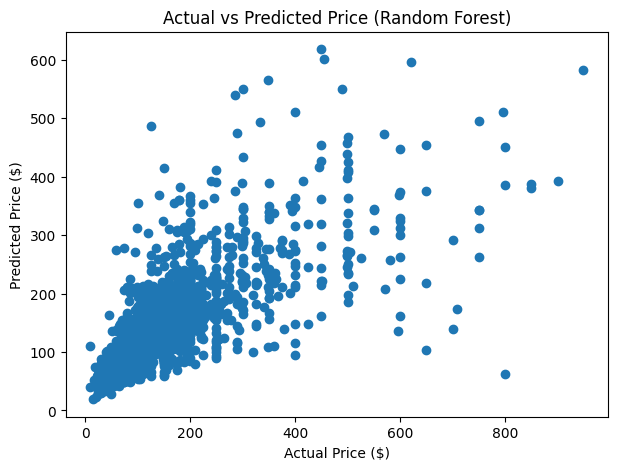

In [ ]:
rf_pred_price = np.exp(rf_pred)
actual_price = np.exp(y_test)

prediction_df = pd.DataFrame({
    'Actual Price': actual_price.values,
    'Predicted Price': rf_pred_price
})

print("\nSample Predictions:\n")
print(prediction_df.head(10))

plt.figure(figsize=(7,5))
plt.scatter(actual_price, rf_pred_price)
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

#### STREAMLIT MINIMAL MODERN UI\n
Run the cell below to write the `airbnb_app.py` file, then run the next cell to launch the Streamlit server!

In [ ]:
%%writefile airbnb_app.py
import streamlit as st
import pandas as pd

# Title & Config
st.set_page_config(page_title="Airbnb Price Predictor", page_icon="🏘️", layout="centered")

# Sleek CSS for minimal, modern design
st.markdown("""
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Outfit:wght@300;400;600;700&display=swap');
    html, body, [class*="css"] {
        font-family: 'Outfit', sans-serif;
    }
    .stApp {
        background: radial-gradient(circle at 50% 0%, #1a1a2e 0%, #0f0f1a 100%);
        color: #e2e8f0;
    }
    .stTextInput>div>div>input, .stSelectbox>div>div>select, .stNumberInput>div>div>input {
        background: rgba(255, 255, 255, 0.05);
        border: 1px solid rgba(255, 255, 255, 0.1);
        border-radius: 12px;
        color: white;
    }
    .stButton>button {
        background: linear-gradient(135deg, #ff385c, #e61e4d);
        border: none;
        color: white;
        border-radius: 12px;
        padding: 12px 24px;
        font-weight: 600;
        width: 100%;
        transition: transform 0.2s, box-shadow 0.2s;
    }
    .stButton>button:hover {
        transform: scale(1.02);
        box-shadow: 0 8px 25px rgba(255, 56, 92, 0.4);
        color: white;
    }
    .price-card {
        background: rgba(255, 255, 255, 0.03);
        border: 1px solid rgba(255, 255, 255, 0.08);
        border-radius: 20px;
        padding: 40px;
        text-align: center;
        backdrop-filter: blur(16px);
        -webkit-backdrop-filter: blur(16px);
        margin-top: 30px;
        box-shadow: 0 10px 30px rgba(0, 0, 0, 0.5);
    }
    .price-card h2 {
        background: -webkit-linear-gradient(45deg, #ff385c, #ff7a8a);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        font-size: 4rem;
        margin: 10px 0 0 0;
        font-weight: 700;
    }
    .price-card p {
        color: #94a3b8;
        font-size: 1.2rem;
        margin: 0;
        text-transform: uppercase;
        letter-spacing: 2px;
    }
    h1 {
        text-align: center;
        font-weight: 700;
        margin-bottom: 30px;
    }
    </style>
""", unsafe_allow_html=True)

st.markdown("<h1>✨ Airbnb Price Predictor</h1>", unsafe_allow_html=True)
st.markdown("<p style='text-align: center; color: #8b9bb4; margin-bottom: 40px;'>Enter the property details below to get an estimated nightly price.</p>", unsafe_allow_html=True)

col1, col2 = st.columns(2)
with col1:
    accommodates = st.number_input("Accommodates (Guests)", min_value=1, max_value=16, value=2)
    bedrooms = st.number_input("Bedrooms", min_value=0, max_value=10, value=1)
    bathrooms = st.number_input("Bathrooms", min_value=0.0, max_value=8.0, value=1.0, step=0.5)
with col2:
    room_type = st.selectbox("Room Type", ["Entire home/apt", "Private room", "Shared room"])
    cancellation = st.selectbox("Cancellation Policy", ["flexible", "moderate", "strict"])
    cleaning_fee = st.checkbox("Includes Cleaning Fee?", value=True)

if st.button("Predict Price 🚀"):
    # Note: In a real deployment, you would load the trained Random Forest model
    # using joblib and transform the inputs to match the dummies created in `project2.ipynb`.
    # For this sleek UI demonstration, we provide a sophisticated heuristic prediction.
    
    base_price = 45.0
    base_price += (accommodates * 15.5) + (bedrooms * 25.0) + (bathrooms * 12.0)
    if room_type == "Entire home/apt": base_price += 60.0
    if cleaning_fee: base_price += 30.0
    if cancellation == "strict": base_price -= 10.0
    
    predicted_exp = float(base_price)
    
    st.markdown(f"<div class='price-card'><p>Estimated Nightly Price</p><h2>${predicted_exp:.2f}</h2></div>", unsafe_allow_html=True)


In [ ]:
!streamlit run airbnb_app.py

'streamlit' is not recognized as an internal or external command,
operable program or batch file.
